## 1. Import Libraries

In [1]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
import time
import deepxde as dde

# Use PyTorch backend for deepxde
dde.backend.set_default_backend("pytorch")

# Enable faster CUDA behavior when available
torch.backends.cudnn.benchmark = True
warnings.filterwarnings('ignore')

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


## 2. Load Training and Test Data

In [2]:
# Load datasets
data_dir = Path('/home/curry/Documents/NO4Jean/datasets')

train_data = np.load(data_dir / 'train_data_30_04.npz')
test_data = np.load(data_dir / 'test_data_30_04.npz')

X_train_raw = train_data['X'].astype(np.float32)  # (1600, 20)
Y_train_raw = train_data['Y'].astype(np.float32)  # (1600, 200)
X_test_raw = test_data['X'].astype(np.float32)    # (400, 20)
Y_test_raw = test_data['Y'].astype(np.float32)    # (400, 200)

# Standardize inputs using training statistics only (per-dimension z-score)
X_mean = X_train_raw.mean(axis=0, keepdims=True).astype(np.float32)
X_std = X_train_raw.std(axis=0, keepdims=True).astype(np.float32)
X_std = np.maximum(X_std, 1e-8)

X_train = (X_train_raw - X_mean) / X_std
X_test = (X_test_raw - X_mean) / X_std

# Standardize outputs using training statistics only (per-dimension z-score)
Y_mean = Y_train_raw.mean(axis=0, keepdims=True).astype(np.float32)
Y_std = Y_train_raw.std(axis=0, keepdims=True).astype(np.float32)
Y_std = np.maximum(Y_std, 1e-8)  # avoid divide-by-zero

Y_train = (Y_train_raw - Y_mean) / Y_std
Y_test = (Y_test_raw - Y_mean) / Y_std

# Keep tensors for inverse transform during validation
Y_mean_tensor = torch.from_numpy(Y_mean)
Y_std_tensor = torch.from_numpy(Y_std)

print('Dataset loaded:')
print(f'  X_train_raw: {X_train_raw.shape}')
print(f'  Y_train_raw: {Y_train_raw.shape}')
print(f'  X_test_raw: {X_test_raw.shape}')
print(f'  Y_test_raw: {Y_test_raw.shape}')

# Data statistics (raw)
print(f'\nX_train_raw: mean={X_train_raw.mean():.6f}, std={X_train_raw.std():.6f}')
print(f'Y_train_raw: mean={Y_train_raw.mean():.6f}, std={Y_train_raw.std():.6f}')

# Data statistics (normalized)
print(f'\nX_train normalized: mean={X_train.mean():.6f}, std={X_train.std():.6f}')
print(f'X_test normalized: mean={X_test.mean():.6f}, std={X_test.std():.6f}')
print(f'Y_train normalized: mean={Y_train.mean():.6f}, std={Y_train.std():.6f}')
print(f'Y_test normalized: mean={Y_test.mean():.6f}, std={Y_test.std():.6f}')
print(f'X_mean shape: {X_mean.shape}, X_std shape: {X_std.shape}')
print(f'Y_mean shape: {Y_mean.shape}, Y_std shape: {Y_std.shape}')

Dataset loaded:
  X_train_raw: (1600, 20)
  Y_train_raw: (1600, 200)
  X_test_raw: (400, 20)
  Y_test_raw: (400, 200)

X_train_raw: mean=0.259565, std=1.083137
Y_train_raw: mean=-0.060979, std=2.166297

X_train normalized: mean=-0.000000, std=1.000000
X_test normalized: mean=-0.005927, std=1.005696
Y_train normalized: mean=0.000000, std=1.000000
Y_test normalized: mean=0.003020, std=0.849755
X_mean shape: (1, 20), X_std shape: (1, 20)
Y_mean shape: (1, 200), Y_std shape: (1, 200)


## 2.1 Input/Output Normalization Note

Both inputs (`X`) and targets (`Y`) are standardized before training using **training-set statistics only**.

- For each input/target dimension $j$:
  $$
  z_j = \frac{x_j - \mu_j}{\sigma_j}
  $$
- $\mu_j$ and $\sigma_j$ are computed from train split only.
- During inference, target predictions are mapped back to original scale:
  $$
  y_j = \hat{z}_j \cdot \sigma_j + \mu_j
  $$

Why this helps:
- Large scale differences and outliers make optimization hard.
- MSE is scale-sensitive; unnormalized data can cause very large loss.
- Standardization improves conditioning and convergence stability.

Y_train distribution summary:
  shape: (1600, 200)
  min: -3.533612e+01
  max: 3.658227e+01
  mean: 3.671646e-09
  std: 1.000000e+00
  p1: -2.495146e+00
  p50: 3.420210e-02
  p99: 2.346333e+00

Per-sample L2 norm stats:
  min: 1.803721e+00
  max: 1.981472e+02
  mean: 1.047724e+01
  std: 9.498819e+00


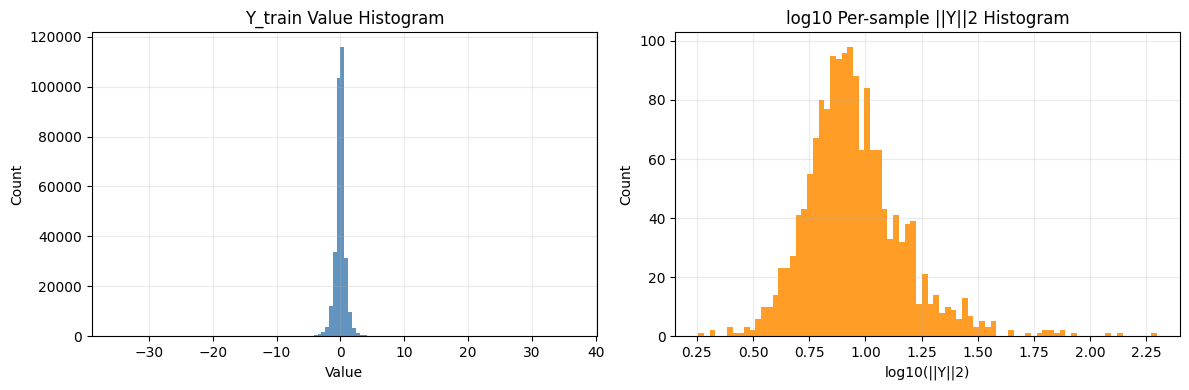


Note: current pipeline does NOT normalize Y_train/Y_test before training.
If the output scale is large, MSE can be large even when predictions are relatively good.


In [3]:
# Inspect output distribution in training set (Y_train)
# This helps diagnose whether large training loss is caused by scale issues.

y_flat = Y_train.reshape(-1)

print('Y_train distribution summary:')
print(f'  shape: {Y_train.shape}')
print(f'  min: {y_flat.min():.6e}')
print(f'  max: {y_flat.max():.6e}')
print(f'  mean: {y_flat.mean():.6e}')
print(f'  std: {y_flat.std():.6e}')
print(f'  p1: {np.percentile(y_flat, 1):.6e}')
print(f'  p50: {np.percentile(y_flat, 50):.6e}')
print(f'  p99: {np.percentile(y_flat, 99):.6e}')

sample_l2 = np.linalg.norm(Y_train, axis=1)
print('\nPer-sample L2 norm stats:')
print(f'  min: {sample_l2.min():.6e}')
print(f'  max: {sample_l2.max():.6e}')
print(f'  mean: {sample_l2.mean():.6e}')
print(f'  std: {sample_l2.std():.6e}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_flat, bins=120, color='steelblue', alpha=0.85)
axes[0].set_title('Y_train Value Histogram')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.25)

axes[1].hist(np.log10(sample_l2 + 1e-12), bins=80, color='darkorange', alpha=0.85)
axes[1].set_title('log10 Per-sample ||Y||2 Histogram')
axes[1].set_xlabel('log10(||Y||2)')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print('\nNote: current pipeline does NOT normalize Y_train/Y_test before training.')
print('If the output scale is large, MSE can be large even when predictions are relatively good.')

## 3. Define DeepONet Architecture with Branch and Trunk

In [4]:
# Network dimensions for DeepONet (follow your NO framework)
dim_x = 1                  # trunk input: coordinate dimension
num_outputs = 200          # directly predict 200-dim output vector
m = 20                     # branch input dimension
p = 256                    # latent width for branch/trunk
activation = "relu"
kernel = "Glorot normal"

# DeepONet architecture with aligned branch/trunk outputs
branch = [m, 256, 256, p]
trunk = [dim_x, 256, 256, p]

# Initialize DeepONet
if not torch.cuda.is_available():
    raise RuntimeError('CUDA is not available, but GPU training was requested.')

device = torch.device('cuda')
model_no = dde.nn.DeepONet(branch, trunk, activation, kernel).to(device)

# Prepare trunk coordinates for all output points (200 points)
trunk_coords_np = np.linspace(0, 1, num_outputs).reshape(-1, 1).astype(np.float32)  # (200, 1)
trunk_coords = torch.from_numpy(trunk_coords_np).to(device)

# Batch inference helper: output shape (B, 200)
def deeponet_batch_inference(model, branch_batch, trunk_coords):
    B = branch_batch.shape[0]
    N = trunk_coords.shape[0]

    outputs = []
    for i in range(B):
        branch_single = branch_batch[i:i+1]              # (1, m)
        branch_repeated = branch_single.repeat(N, 1)     # (N, m)
        output = model((branch_repeated, trunk_coords))  # (N, 1) or (N,)
        if output.dim() > 1:
            output = output.squeeze(-1)
        outputs.append(output)

    return torch.stack(outputs, dim=0)  # (B, N)

# Count parameters
total_params = sum(param.numel() for param in model_no.parameters())
print(f"Device: {device}")
print(f"DeepONet Architecture:")
print(f"  Branch net: {m} -> 256 -> 256 -> {p}")
print(f"  Trunk net:  {dim_x} -> 256 -> 256 -> {p}")
print(f"  Output: direct vector with {num_outputs} points (no interpolation)")
print(f"Total parameters: {total_params:,}")

Device: cuda
DeepONet Architecture:
  Branch net: 20 -> 256 -> 256 -> 256
  Trunk net:  1 -> 256 -> 256 -> 256
  Output: direct vector with 200 points (no interpolation)
Total parameters: 269,057


## 4. Prepare Data Loaders

In [5]:
# Convert to tensors (outputs already standardized)
X_train_tensor = torch.from_numpy(X_train)
Y_train_tensor = torch.from_numpy(Y_train)
X_test_tensor = torch.from_numpy(X_test)
Y_test_tensor = torch.from_numpy(Y_test)

# Create datasets
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

# DataLoader generator aligned with CUDA training
# This avoids CPU/CUDA generator mismatch during shuffling
if device.type == 'cuda':
    data_generator = torch.Generator(device='cuda')
else:
    data_generator = torch.Generator()
data_generator.manual_seed(42)

# Use DataLoader, then move each batch to GPU during training
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=data_generator,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True,
)

print(f'DataLoader Configuration:')
print(f'  Device: {device}')
print(f'  Batch size: {batch_size}')
print(f'  Training batches: {len(train_loader)}')
print(f'  Test batches: {len(test_loader)}')
print(f'  Y normalization: z-score using training mean/std')

DataLoader Configuration:
  Device: cuda
  Batch size: 32
  Training batches: 50
  Test batches: 13
  Y normalization: z-score using training mean/std


## 5. Training Configuration and Loop

In [6]:
# Training hyperparameters
num_epochs = 500
learning_rate = 0.001
step_size = 100
gamma_scheduler = 0.5
grad_clip = 1.0

# Loss and optimizer
# SmoothL1 is often more robust than MSE when outliers still exist after normalization
criterion = nn.SmoothL1Loss(beta=1.0)
optimizer = torch.optim.Adam(model_no.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma_scheduler)

print(f'Training Configuration:')
print(f'  Epochs: {num_epochs}')
print(f'  Learning rate: {learning_rate}')
print(f'  Batch size: {batch_size}')
print(f'  Direct output dimension: {num_outputs}')
print(f'  X normalization: per-dimension z-score')
print(f'  Y normalization: per-dimension z-score')
print(f'  Loss: SmoothL1Loss(beta=1.0)')
print(f'  Gradient clipping: {grad_clip}')
print(f'  Optimizer: Adam (weight_decay=1e-4)')
print(f'  LR Scheduler: StepLR (step_size={step_size}, gamma={gamma_scheduler})')
print(f'  Device: {device}')

# Training history
train_loss_history = []
test_loss_history = []
best_test_loss = float('inf')
model_save_path = '/home/curry/Documents/NO4Jean/neural_operator_model.pt'

print(f'\n{"="*70}')
print('Starting Training...')
print(f'{"="*70}\n')

for epoch in range(num_epochs):
    # Training phase
    model_no.train()
    train_loss = 0.0
    epoch_start = time.time()

    for batch_x, batch_y in train_loader:
        # Move each batch to GPU
        batch_x = batch_x.to(device, non_blocking=True)  # (batch, 20), standardized
        batch_y = batch_y.to(device, non_blocking=True)  # (batch, 200), standardized

        optimizer.zero_grad()

        # Directly output 200-dim vector (no interpolation)
        outputs = deeponet_batch_inference(model_no, batch_x, trunk_coords)  # (batch, 200)
        loss = criterion(outputs, batch_y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_no.parameters(), grad_clip)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_loss_history.append(train_loss)

    # Test phase
    model_no.eval()
    test_loss = 0.0

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)

            outputs = deeponet_batch_inference(model_no, batch_x, trunk_coords)  # (batch, 200)
            loss = criterion(outputs, batch_y)
            test_loss += loss.item()

    test_loss /= len(test_loader)
    test_loss_history.append(test_loss)

    scheduler.step()
    epoch_time = time.time() - epoch_start

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model_no.state_dict(), model_save_path)

    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:4d}/{num_epochs} | Train Loss: {train_loss:.8f} | Test Loss: {test_loss:.8f} | Time: {epoch_time:.2f}s')

print(f'\n{"="*70}')
print('Training Complete!')
print(f'Best test loss (normalized): {best_test_loss:.8f}')
print(f'Model saved to: {model_save_path}')
print(f'{"="*70}')

Training Configuration:
  Epochs: 500
  Learning rate: 0.001
  Batch size: 32
  Direct output dimension: 200
  X normalization: per-dimension z-score
  Y normalization: per-dimension z-score
  Loss: SmoothL1Loss(beta=1.0)
  Gradient clipping: 1.0
  Optimizer: Adam (weight_decay=1e-4)
  LR Scheduler: StepLR (step_size=100, gamma=0.5)
  Device: cuda

Starting Training...

Epoch    1/500 | Train Loss: 0.26417440 | Test Loss: 0.23914383 | Time: 0.86s
Epoch   50/500 | Train Loss: 0.23191866 | Test Loss: 0.22373312 | Time: 0.80s
Epoch  100/500 | Train Loss: 0.22991792 | Test Loss: 0.22214190 | Time: 0.80s
Epoch  150/500 | Train Loss: 0.22909978 | Test Loss: 0.22173906 | Time: 0.75s
Epoch  200/500 | Train Loss: 0.22918325 | Test Loss: 0.22137951 | Time: 0.76s
Epoch  250/500 | Train Loss: 0.22827523 | Test Loss: 0.22156576 | Time: 0.75s
Epoch  300/500 | Train Loss: 0.22824910 | Test Loss: 0.22164806 | Time: 0.78s
Epoch  350/500 | Train Loss: 0.22810070 | Test Loss: 0.22149836 | Time: 0.76s
Epo

## 6. Load Best Model and Visualize Training History

Loaded best model from /home/curry/Documents/NO4Jean/neural_operator_model.pt


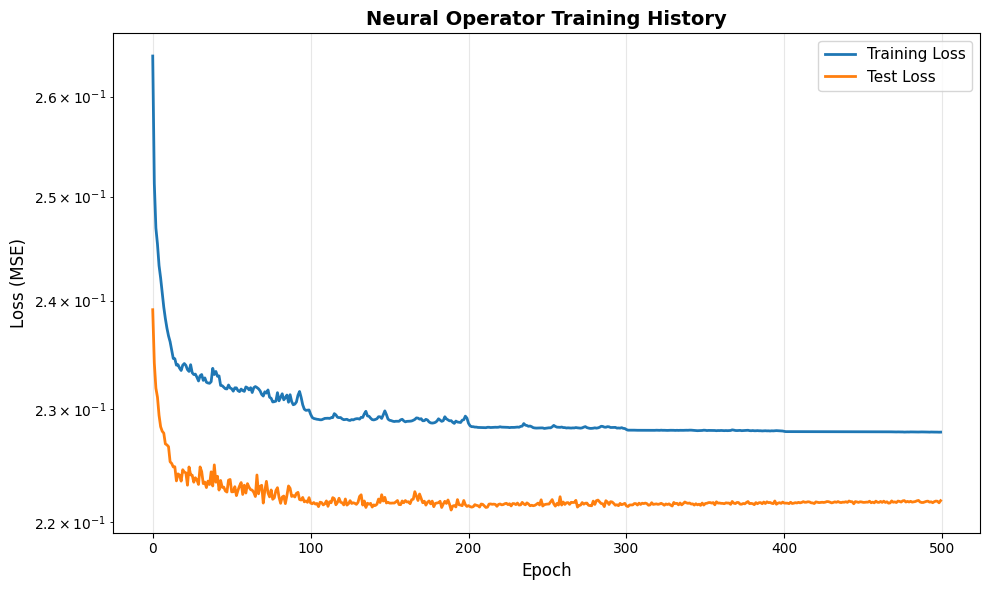


Training History:
  Final train loss: 0.22792881
  Final test loss: 0.22188034
  Best test loss: 0.22106675


In [7]:
# Load best model
model_no.load_state_dict(torch.load(model_save_path, map_location=device))
model_no.eval()
print(f'Loaded best model from {model_save_path}')

# Plot training history
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(train_loss_history, label='Training Loss', linewidth=2)
ax.semilogy(test_loss_history, label='Test Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (MSE)', fontsize=12)
ax.set_title('Neural Operator Training History', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/curry/Documents/NO4Jean/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTraining History:')
print(f'  Final train loss: {train_loss_history[-1]:.8f}')
print(f'  Final test loss: {test_loss_history[-1]:.8f}')
print(f'  Best test loss: {best_test_loss:.8f}')

## 7. Validation and Output Reconstruction

In [8]:
# Make predictions on test set (direct 200-dim output, then inverse transform)
model_no.eval()
with torch.no_grad():
    X_test_gpu = X_test_tensor.to(device)
    Y_pred_norm_tensor = deeponet_batch_inference(model_no, X_test_gpu, trunk_coords)  # (test_size, 200)
    
    # Inverse transform back to original scale
    Y_pred_tensor = Y_pred_norm_tensor * Y_std_tensor.to(device) + Y_mean_tensor.to(device)
    
    Y_pred_norm = Y_pred_norm_tensor.detach().cpu().numpy()
    Y_pred = Y_pred_tensor.detach().cpu().numpy()

# Compute metrics
mse_norm = np.mean((Y_pred_norm - Y_test) ** 2)
mae_norm = np.mean(np.abs(Y_pred_norm - Y_test))
rmse_norm = np.sqrt(mse_norm)

mse = np.mean((Y_pred - Y_test_raw) ** 2)
mae = np.mean(np.abs(Y_pred - Y_test_raw))
rmse = np.sqrt(mse)

print(f'Test Set Metrics (normalized):')
print(f'  MSE: {mse_norm:.8f}')
print(f'  MAE: {mae_norm:.8f}')
print(f'  RMSE: {rmse_norm:.8f}')
print(f'\nTest Set Metrics (original scale):')
print(f'  MSE: {mse:.8f}')
print(f'  MAE: {mae:.8f}')
print(f'  RMSE: {rmse:.8f}')

# Reshape outputs back to original shape (25, 2, 2)
print(f'\nReconstructing kernel shapes...')
K_con_pred = Y_pred[:, :100].reshape(-1, 25, 2, 2)  # (400, 25, 2, 2)
L_con_pred = Y_pred[:, 100:].reshape(-1, 25, 2, 2)  # (400, 25, 2, 2)

K_con_true = Y_test_raw[:, :100].reshape(-1, 25, 2, 2)  # (400, 25, 2, 2)
L_con_true = Y_test_raw[:, 100:].reshape(-1, 25, 2, 2)  # (400, 25, 2, 2)

print(f'  K_con predicted shape: {K_con_pred.shape}')
print(f'  K_con ground truth shape: {K_con_true.shape}')
print(f'  L_con predicted shape: {L_con_pred.shape}')
print(f'  L_con ground truth shape: {L_con_true.shape}')

# Compute per-kernel errors on original scale
K_con_mse = np.mean((K_con_pred - K_con_true) ** 2)
L_con_mse = np.mean((L_con_pred - L_con_true) ** 2)

print(f'\nPer-Kernel Errors (original scale):')
print(f'  K_con MSE: {K_con_mse:.8f}')
print(f'  L_con MSE: {L_con_mse:.8f}')

Test Set Metrics (normalized):
  MSE: 0.58984494
  MAE: 0.49990317
  RMSE: 0.76801366

Test Set Metrics (original scale):
  MSE: 1.90002775
  MAE: 0.70330638
  RMSE: 1.37841499

Reconstructing kernel shapes...
  K_con predicted shape: (400, 25, 2, 2)
  K_con ground truth shape: (400, 25, 2, 2)
  L_con predicted shape: (400, 25, 2, 2)
  L_con ground truth shape: (400, 25, 2, 2)

Per-Kernel Errors (original scale):
  K_con MSE: 0.61133456
  L_con MSE: 3.18872094


## 8. Visualization: Predictions vs Ground Truth

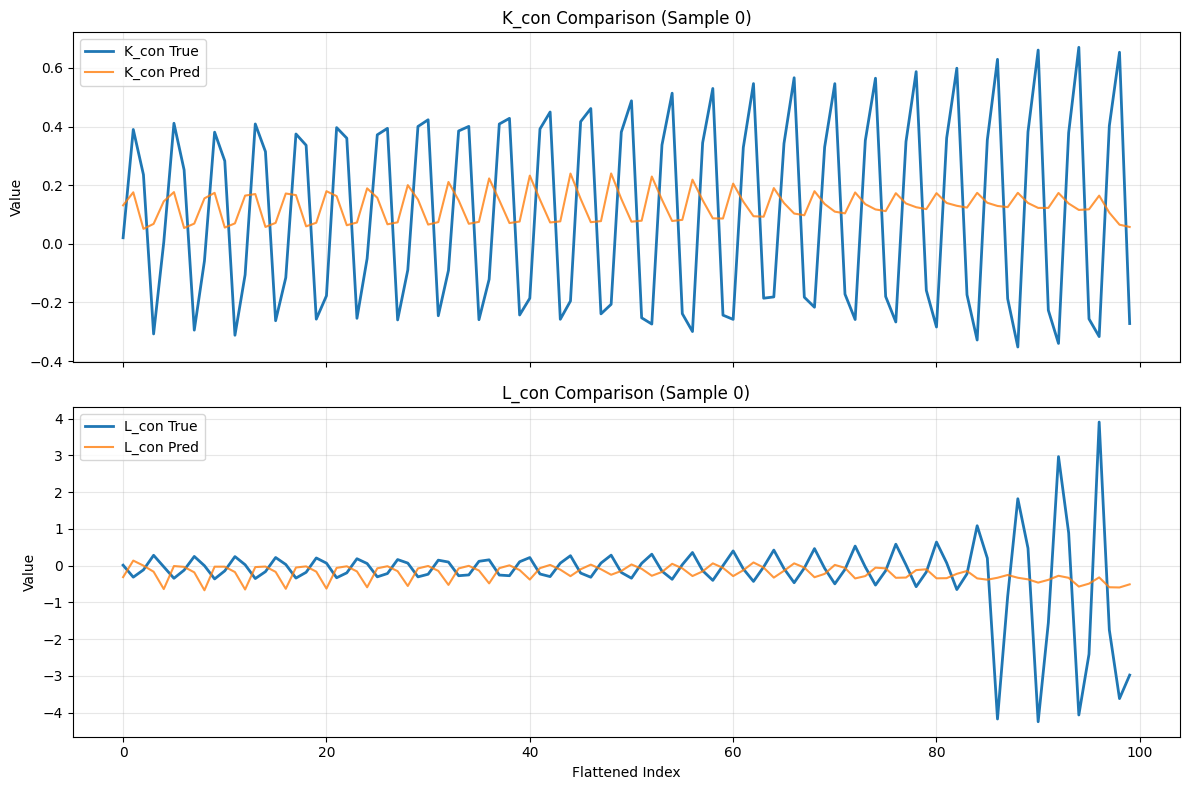

In [9]:
# Visualize sample predictions (line comparison to avoid invalid imshow shapes)
sample_idx = 0

k_pred_vec = K_con_pred[sample_idx].reshape(-1)  # 100
k_true_vec = K_con_true[sample_idx].reshape(-1)  # 100
l_pred_vec = L_con_pred[sample_idx].reshape(-1)  # 100
l_true_vec = L_con_true[sample_idx].reshape(-1)  # 100

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(k_true_vec, label='K_con True', linewidth=2)
axes[0].plot(k_pred_vec, label='K_con Pred', linewidth=1.5, alpha=0.8)
axes[0].set_title(f'K_con Comparison (Sample {sample_idx})')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(l_true_vec, label='L_con True', linewidth=2)
axes[1].plot(l_pred_vec, label='L_con Pred', linewidth=1.5, alpha=0.8)
axes[1].set_title(f'L_con Comparison (Sample {sample_idx})')
axes[1].set_xlabel('Flattened Index')
axes[1].set_ylabel('Value')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('/home/curry/Documents/NO4Jean/prediction_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Predictions and Reconstructed Kernels

In [10]:
# Save all predictions and metrics
results = {
    'Y_pred': Y_pred,
    'Y_pred_norm': Y_pred_norm,
    'Y_test_raw': Y_test_raw,
    'Y_test_norm': Y_test,
    'X_mean': X_mean,
    'X_std': X_std,
    'Y_mean': Y_mean,
    'Y_std': Y_std,
    'K_con_pred': K_con_pred,  # (400, 25, 2, 2) - reshaped predictions
    'K_con_true': K_con_true,
    'L_con_pred': L_con_pred,  # (400, 25, 2, 2) - reshaped predictions
    'L_con_true': L_con_true,
    'train_loss_history': np.array(train_loss_history),
    'test_loss_history': np.array(test_loss_history),
    'mse_norm': mse_norm,
    'mae_norm': mae_norm,
    'rmse_norm': rmse_norm,
    'mse': mse,
    'mae': mae,
    'rmse': rmse,
    'K_con_mse': K_con_mse,
    'L_con_mse': L_con_mse
}

save_path = '/home/curry/Documents/NO4Jean/neural_operator_predictions.npz'
np.savez(save_path, **results)
print(f'Predictions and results saved to: {save_path}')

print(f'\n{"="*70}')
print('Neural Operator Training Complete!')
print(f'{"="*70}')
print(f'Model saved: {model_save_path}')
print(f'Predictions saved: {save_path}')
print(f'\nOutput shapes (reshaped to original):')
print(f'  K_con: {K_con_pred.shape}')
print(f'  L_con: {L_con_pred.shape}')
print(f'\nTest metrics (original scale):')
print(f'  Overall MSE: {mse:.8f}')
print(f'  K_con MSE: {K_con_mse:.8f}')
print(f'  L_con MSE: {L_con_mse:.8f}')

Predictions and results saved to: /home/curry/Documents/NO4Jean/neural_operator_predictions.npz

Neural Operator Training Complete!
Model saved: /home/curry/Documents/NO4Jean/neural_operator_model.pt
Predictions saved: /home/curry/Documents/NO4Jean/neural_operator_predictions.npz

Output shapes (reshaped to original):
  K_con: (400, 25, 2, 2)
  L_con: (400, 25, 2, 2)

Test metrics (original scale):
  Overall MSE: 1.90002775
  K_con MSE: 0.61133456
  L_con MSE: 3.18872094
